In [1]:
import qiskit

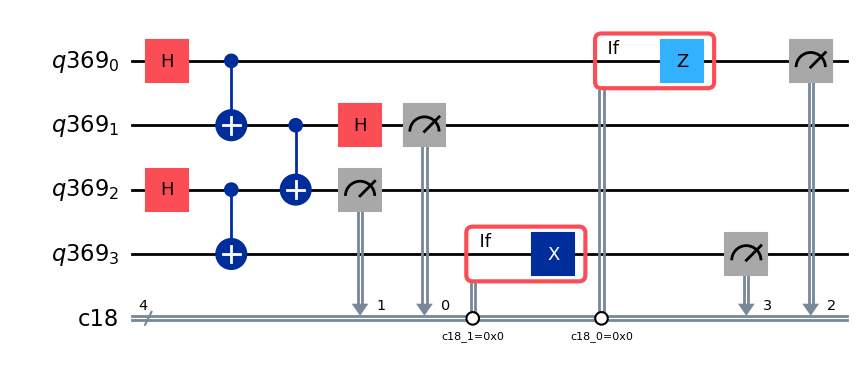

In [91]:
cl = qiskit.ClassicalRegister(4)
qr = qiskit.QuantumRegister(4)
qc = qiskit.QuantumCircuit(qr, cl)
qc.h(0)
qc.h(2)
qc.cx(0,1)
qc.cx(2,3)
qc.cx(1,2)
qc.h(1)
qc.measure(1, cl[0])
qc.measure(2, cl[1])
with qc.if_test((cl[0], 1)):
    qc.z(0)
with qc.if_test((cl[1], 1)):
    qc.x(3)

qc.measure(0, cl[2])
qc.measure(3, cl[3])

qc.draw('mpl')

In [92]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
simulator = Aer.get_backend('qasm_simulator') 
#result = execute(circuit, simulator, shots=1000).result()
simulator = AerSimulator()
ShotNum=1000
circ = transpile(qc, simulator)
result = simulator.run(circ,shots=ShotNum).result()
counts = result.get_counts(qc)
counts

{'1011': 113,
 '1010': 138,
 '1001': 112,
 '0100': 127,
 '1000': 114,
 '0111': 125,
 '0101': 143,
 '0110': 128}